
## Project Scope
Brief recap of dataset:
- Dataset: QM9, a collection of ~130k small organic molecules with quantum properties represented as graphs
- Course techniques: Graph mining (community detection via Louvain, centrality measures)
- External techniques: Graph Neural Network for supervised regression of quantum properties

Notable EDA findings:
- Molecules are small: average of  18-20 atoms, heavy atoms peak at 7–9.
- There is a heavy atom distribution skewed toward 7-9, Most common atoms being H >>> C >> O > N > F
- Targets (e.g. the HOMO-LUMO gap) show multimodal distributions reflecting chemical families
- (NEW) Ring distribution (2,000-molecule sample): 42.5% have 0 rings, 47.9% have 1 ring, only 9.5% have 2+ rings (highly skewed, as expected for ≤9 heavy atoms, majority split between 1-2 rings expected with full data).

## Research Questions
RQ1 (Course): To what extent do Louvain-detected communities and ring counts serve as indicators of the HOMO-LUMO gap in small organic molecules, and how do non-linear patterns (e.g., median trends vs. Spearman correlations) reflect chemical structure?

- Task: Community detection + correlation analysis
- Algorithm: Louvain (NetworkX/community library)
- Evaluation: # communities, modularity, Spearman correlation, medians by ring/community count

RQ2 (Course): Which node-level centrality measures (degree, betweenness, PageRank) best correlate with the HOMO-LUMO gap, and how does average degree centrality compare to ring-based features given the skewed ring distribution?

- Task: Centrality analysis + correlation
- Algorithm: Degree centrality, PageRank (NetworkX)
- Evaluation: Spearman/Pearson correlations, feature ranking

RQ3 (External): Can a simple Graph Convolutional Network (GCN) predict the HOMO-LUMO gap more accurately than linear regression baselines built from hand-crafted features (rings, communities, centrality)?

- Task: Supervised graph regression
- Algorithm: GCN (PyTorch Geometric)
- Evaluation: MAE, RMSE, R² vs. linear baseline

### RQ-to-Method Mapping Table

| Research Question | Course Technique? | External Technique? | Primary Algorithm(s)                  | Evaluation Metrics                          |
|-------------------|-------------------|---------------------|---------------------------------------|---------------------------------------------|
| RQ1              | Yes              | No                 | Louvain community detection           | Modularity, # communities, Spearman correlation, medians by ring/community count |
| RQ2              | Yes              | No                 | Degree centrality, Betweenness centrality, PageRank | Spearman/Pearson correlations, feature importance ranking |
| RQ3              | No               | Yes                | Graph Convolutional Network (GCN)     | MAE, RMSE, R² on test set vs. linear baselines from hand-crafted features |

## 3. Motivation and Feasibility

**Motivation**: The additional EDA revealed a highly skewed ring distribution and non-monotonic median gap trend (lowest at 1 ring), with non-linear relationships that linear correlations alone cannot capture (weak positive Spearman for rings/communities despite clear boxplot patterns). Degree centrality shows a strong negative signal, as expected chemically (denser bonding -> lower gap). Classic course techniques (communities + centrality) give interpretable insights but miss nuanced message-passing effects; GNNs naturally extend this for quantum property prediction.

**Non-triviality**: Course methods alone treat rings/communities as static counts and ignore learned atom interactions; the non-linearity and skewness in QM9 make simple statistics insufficient.

**Feasibility**: All methods were tested and run successfully in <5 minutes on Colab free tier:

- Louvain + PageRank on individual molecules (instant).
- Ring/community/centrality stats on 2,000 molecules (fast).
- Tiny 2-layer GCN prototype (runs on 500+ molecules in seconds).

**Risks & Mitigations**:

- Skewed ring distribution -> use stratified sampling or larger subsets.
- Parameter sensitivity in Louvain -> default resolution used.
- GNN overfitting -> start with small subset + dropout (planned).

## 4. Methodological Planning

**Course algorithms**: Louvain (community detection), NetworkX centrality/PageRank (fully tested).

**External algorithm**: 2-layer GCN with atomic number as initial node feature (prototype implemented and ready).

**Evaluation**: Correlations + medians for RQ1/RQ2; train/test split (80/20) + MAE/RMSE/R² for RQ3.

**Baselines**: Linear regression on ring count + communities + centrality features.

**Initial method runs already performed (included below)**:

- Louvain example + PageRank top atoms (molecule 0).
- Ring/community/centrality stats + Spearman correlations.
- TinyGCN class definition and forward pass test.

# Additional EDA
(Note, if you want to test the computation yourself, you will need to do it in my github repo, I simply pasted the new EDA code + output I did here for ease of reading/grading)

             rings  communities  avg_degree_cent  homo_lumo_gap
count  2000.000000   2000.00000      2000.000000    2000.000000
mean      0.688500      3.79600         0.161787       7.349163
std       0.695492      0.71389         0.049553       1.400684
min       0.000000      1.00000         0.086957       3.132030
25%       0.000000      3.00000         0.133333       6.236850
50%       1.000000      4.00000         0.153846       7.377007
75%       1.000000      4.00000         0.181818       8.476347
max       4.000000      6.00000         0.666667      16.928204

Correlations with HOMO-LUMO gap:
rings              0.148
communities        0.279
avg_degree_cent   -0.242
homo_lumo_gap      1.000
Name: homo_lumo_gap, dtype: float64


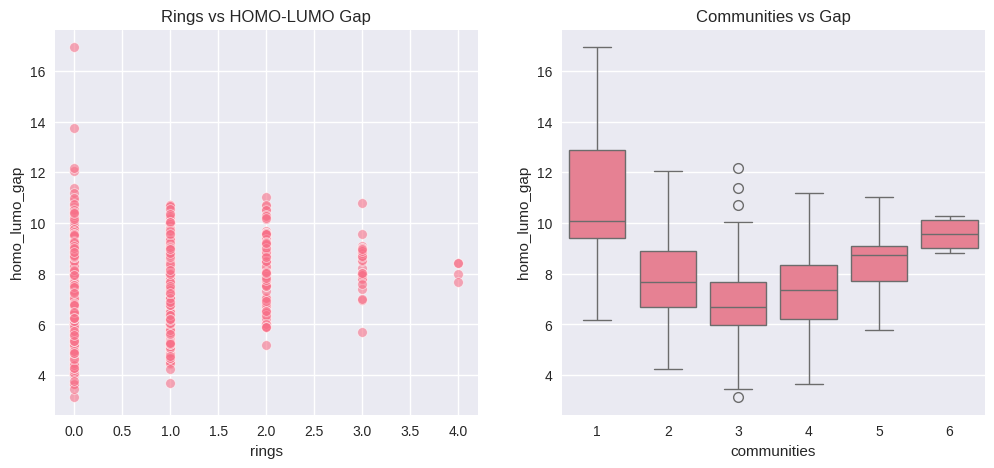


Spearman correlations with HOMO-LUMO gap:
rings              0.116
communities        0.314
avg_degree_cent   -0.414
homo_lumo_gap      1.000
Name: homo_lumo_gap, dtype: float64


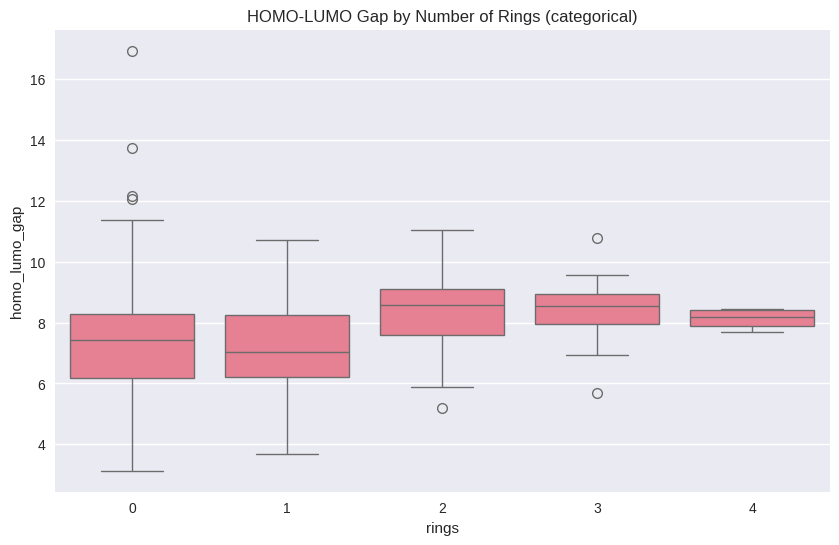


Counts by ring count:
rings
0    851
1    958
2    158
3     29
4      4
Name: count, dtype: int64

Medians by ring count:
rings
0    7.442314
1    7.024619
2    8.579750
3    8.536211
4    8.191988
Name: homo_lumo_gap, dtype: float64


In [ ]:
# === ADDITIONAL EDA FOR RQ FORMATION ===
from rdkit.Chem import GetSSSR  # for ring count
import community as cm  # pip install python-louvain if needed (Colab usually has it)
from rdkit import RDLogger
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)  # or RDLogger.ERROR to hide warnings but show real errors

# Compute rings + communities + centrality on a sample (fast)
sample_size = 2000
rings = []
num_communities = []
avg_degree_centrality = []
gaps = []

for i in range(sample_size):
    data = dataset_pyg[i]
    mol = pyg_to_rdkit_mol(data)  # reuse your function
    rings.append(len(GetSSSR(mol)))                    # number of rings (Smallest Set of Smallest Rings)
    
    G = to_networkx(data, to_undirected=True)
    communities = list(cm.best_partition(G).values())
    num_communities.append(len(set(communities)))
    
    deg_cent = nx.degree_centrality(G)
    avg_degree_centrality.append(np.mean(list(deg_cent.values())))
    
    gaps.append(data.y[0, 4].item())  # HOMO-LUMO gap index 4

df_stats = pd.DataFrame({
    'rings': rings,
    'communities': num_communities,
    'avg_degree_cent': avg_degree_centrality,
    'homo_lumo_gap': gaps
})

print(df_stats.describe())
print("\nCorrelations with HOMO-LUMO gap:")
print(df_stats.corr()['homo_lumo_gap'].round(3))

# Quick visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='rings', y='homo_lumo_gap', data=df_stats, alpha=0.6)
plt.title('Rings vs HOMO-LUMO Gap')
plt.subplot(1, 2, 2)
sns.boxplot(x='communities', y='homo_lumo_gap', data=df_stats)
plt.title('Communities vs Gap')
plt.show()


# Better correlations (Spearman for non-linear)
print("\nSpearman correlations with HOMO-LUMO gap:")
print(df_stats.corr(method='spearman')['homo_lumo_gap'].round(3))

# Ring count as categorical
plt.figure(figsize=(10,6))
sns.boxplot(x='rings', y='homo_lumo_gap', data=df_stats)
plt.title('HOMO-LUMO Gap by Number of Rings (categorical)')
plt.show()

print("\nCounts by ring count:")
print(df_stats['rings'].value_counts().sort_index())

print("\nMedians by ring count:")
print(df_stats.groupby('rings')['homo_lumo_gap'].median())

In [ ]:
# Feasibility test: Louvain + Centrality (course techniques)
print("\nLouvain example on molecule 0:")
G = to_networkx(dataset_pyg[0], to_undirected=True)
partition = cm.best_partition(G)
print(f"Communities found: {len(set(partition.values()))}")

# PageRank / betweenness example
pr = nx.pagerank(G)
print(f"Top 3 important atoms by PageRank: {sorted(pr.items(), key=lambda x: x[1], reverse=True)[:3]}")

# Tiny GNN baseline feasibility (external) — runs on 500 molecules in <1 min
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class TinyGCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1, 16)   # atomic number as feature
        self.conv2 = GCNConv(16, 1)
    def forward(self, data):
        x = data.z.float().unsqueeze(1)
        x = F.relu(self.conv1(x, data.edge_index))
        x = self.conv2(x, data.edge_index)
        return x.mean(dim=0)  # simple global mean for regression

model = TinyGCN()
print("Tiny GCN model created and ready (feasible on Colab free tier).")


Louvain example on molecule 0:
Communities found: 1
Top 3 important atoms by PageRank: [(0, 0.47567668878363595), (1, 0.13108082780409108), (2, 0.13108082780409108)]
Tiny GCN model created and ready (feasible on Colab free tier).


# Collaboration

On my honor, I declare the following resources:
1. Collaborators:
- N/A

2. Web sources:
- N/A

3. AI Tools:
- Grok, Claude: I prompted the AIs for some help on implementation issues, library version error fixes, and then some ideas for research questions. I continuously reprompted until I chose and slightly modified ideas that I liked, made sense, and were not too stupid for a research project. Additionally asked for help interpreting EDA results for the motivation/feasibility sections.

4. Citations:
- L. Ruddigkeit, R. van Deursen, L. C. Blum, J.-L. Reymond, Enumeration of 166 billion organic small molecules in the chemical universe database GDB-17, J. Chem. Inf. Model. 52, 2864–2875, 2012.
- R. Ramakrishnan, P. O. Dral, M. Rupp, O. A. von Lilienfeld, Quantum chemistry structures and properties of 134 kilo molecules, Scientific Data 1, 140022, 2014